# **TRAINING MODEL**

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import MinMaxScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    silhouette_score)

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Load Data

In [4]:
df = pd.read_csv(
    "../data/data_kos_raw.csv",
    sep=";")

print(df.shape)
df.head()

(160, 11)


,Nama Kos,Alamat,Jenis,Harga,WiFi,AC,Dapur,Listrik,Kamar mandi,Jarak dari PENS,Nomor pemilik kos
0,Kos Muslimah,Keputih gang 2b nomor 28,Khusus Perempuan,800000,Ada,Tidak,Ada,Include,Luar,"2,8",+62 895-3970-76143
1,Kos The Gayam,Jalan wismpa permai ix no 21,Khusus Perempuan,1.600.000,Ada,Ada,Ada,Exclude,Luar,2.4,+62 811-314-413
2,Griya Risny TMB 114,Tegal Mulyorejo Baru No.114,Khusus Perempuan,800.000,Ada,Tidak,Ada,Include,Luar,1.0,81259401184
3,Kos Khoirul Huda,Jalan Semampir Selatan IIA,Campur,275000,Ada,Tidak,Ada,Include,Luar,6.0,81230303153
4,Kos pak Mirza E20,"Keputih Gg makam, Blok E20",Khusus Laki Laki,450000,Ada,Tidak,Tidak,Include,Luar,"3,3",+62 851-0091-8223


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Nama Kos           160 non-null    object
 1   Alamat             160 non-null    object
 2   Jenis              160 non-null    object
 3   Harga              160 non-null    object
 4   WiFi               160 non-null    object
 5   AC                 160 non-null    object
 6   Dapur              160 non-null    object
 7   Listrik            160 non-null    object
 8   Kamar mandi        160 non-null    object
 9   Jarak dari PENS    160 non-null    object
 10  Nomor pemilik kos  69 non-null     object
dtypes: object(11)
memory usage: 13.9+ KB


In [6]:
df.describe(include="all")

,Nama Kos,Alamat,Jenis,Harga,WiFi,AC,Dapur,Listrik,Kamar mandi,Jarak dari PENS,Nomor pemilik kos
count,160,160,160,160,160,160,160,160,160,160,69
unique,158,74,3,55,2,2,2,2,2,46,66
top,Kos Muslimah,Sukolilo,Khusus Laki Laki,750000,Ada,Tidak,Ada,Exclude,Luar,2.0,+62 823-3022-0330
freq,2,48,80,14,149,84,126,87,109,12,3


In [ ]:
display(df[["Harga", "Jarak dari PENS"]]
    .head(10))

,Harga,Jarak dari PENS
0,800000,"2,8"
1,1.600.000,2.4
2,800.000,1.0
3,275000,6.0
4,450000,"3,3"
5,875000,"1,4"
6,1250000,0.5
7,700000,2.1
8,800000,1.5
9,700000,2.0


In [8]:
df["Harga"] = (
    df["Harga"]
    .astype(str)
    .str.replace(".", "", regex=False))

df["Harga"] = pd.to_numeric(
    df["Harga"],
    errors="coerce")

In [9]:
df["Jarak dari PENS"] = (
    df["Jarak dari PENS"]
    .astype(str)
    .str.replace(",", ".", regex=False))

df["Jarak dari PENS"] = pd.to_numeric(
    df["Jarak dari PENS"],
    errors="coerce")

In [10]:
df.isnull().sum()

Nama Kos              0
Alamat                0
Jenis                 0
Harga                 0
WiFi                  0
AC                    0
Dapur                 0
Listrik               0
Kamar mandi           0
Jarak dari PENS       0
Nomor pemilik kos    91
dtype: int64

In [11]:
print("Duplicate :", df.duplicated().sum())

Duplicate : 0


# EDA

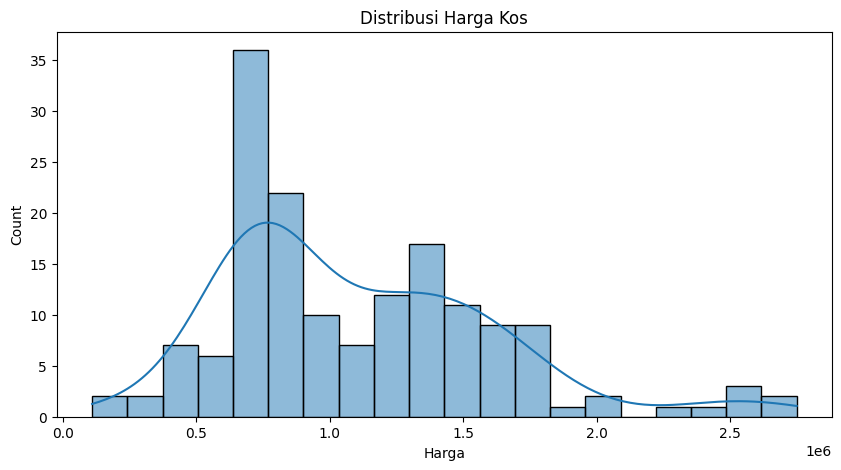

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Harga",
    bins=20,
    kde=True)

plt.title("Distribusi Harga Kos")
plt.show()

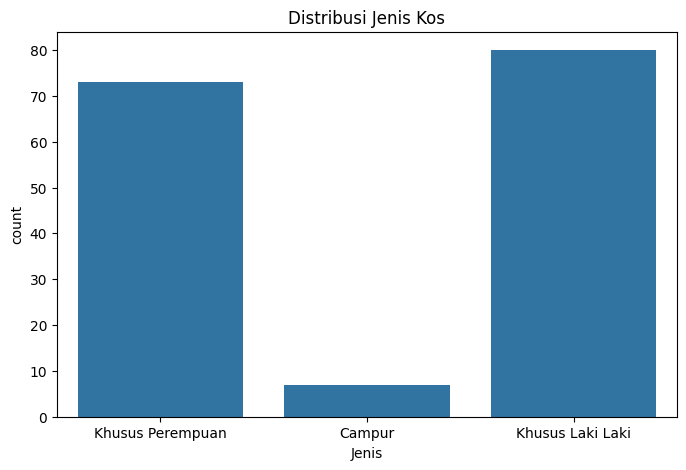

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Jenis")

plt.title("Distribusi Jenis Kos")
plt.show()

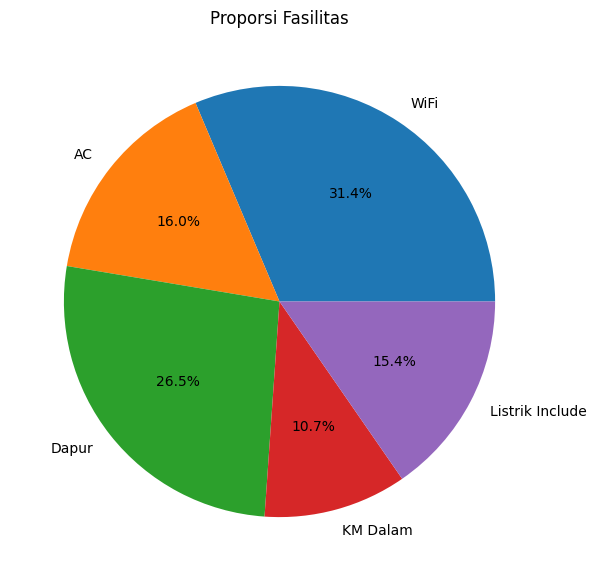

In [14]:
wifi = (df["WiFi"] == "Ada").sum()
ac = (df["AC"] == "Ada").sum()
dapur = (df["Dapur"] == "Ada").sum()
km = (df["Kamar mandi"] == "Dalam").sum()
listrik = (df["Listrik"] == "Include").sum()

fasilitas = [
    wifi,
    ac,
    dapur,
    km,
    listrik]

labels = [
    "WiFi",
    "AC",
    "Dapur",
    "KM Dalam",
    "Listrik Include"]

plt.figure(figsize=(7,7))

plt.pie(
    fasilitas,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Proporsi Fasilitas")
plt.show()

In [15]:
mapping_ada = {
    "Ada": 1,
    "Tidak": 0}

mapping_listrik = {
    "Include": 1,
    "Exclude": 0}

mapping_km = {
    "Dalam": 1,
    "Luar": 0}

In [16]:
df_corr = df.copy()

df_corr["WiFi"] = df_corr["WiFi"].map(mapping_ada)
df_corr["AC"] = df_corr["AC"].map(mapping_ada)
df_corr["Dapur"] = df_corr["Dapur"].map(mapping_ada)
df_corr["Listrik"] = df_corr["Listrik"].map(mapping_listrik)
df_corr["Kamar mandi"] = df_corr["Kamar mandi"].map(mapping_km)

df_corr = pd.get_dummies(
    df_corr,
    columns=["Jenis"]
)

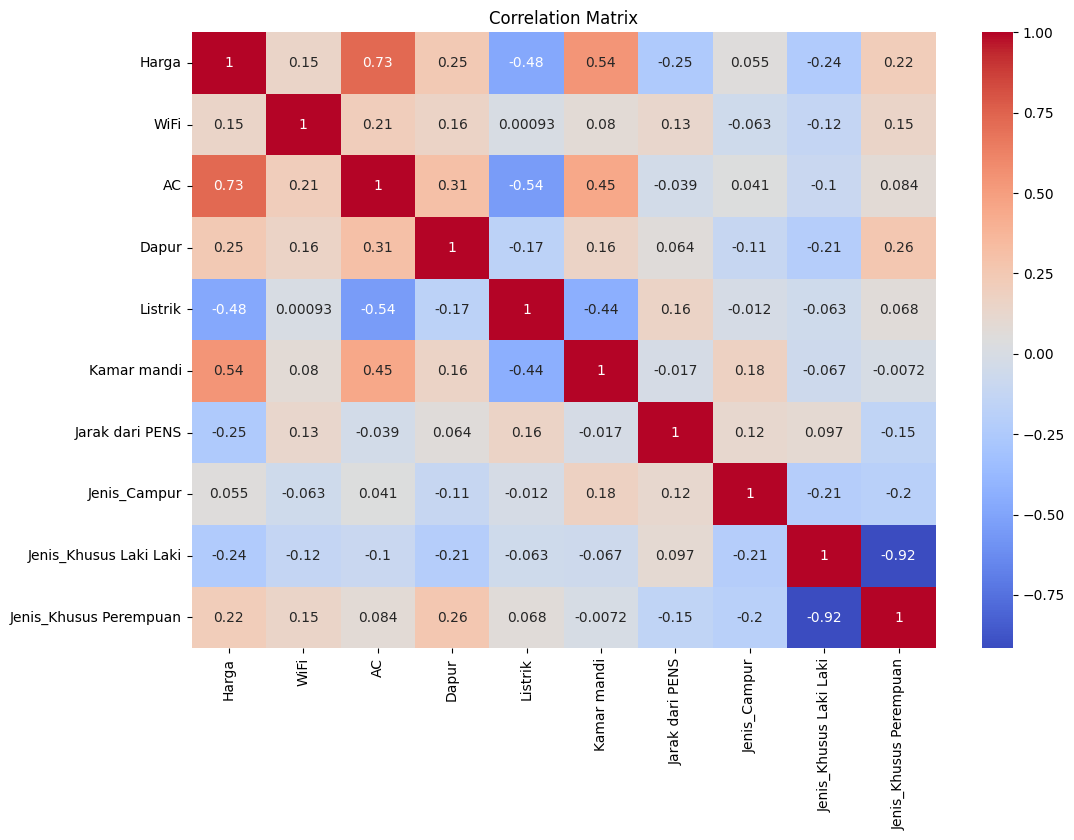

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

In [19]:
df_regresi = df.copy()

df_regresi["WiFi"] = df_regresi["WiFi"].map(mapping_ada)
df_regresi["AC"] = df_regresi["AC"].map(mapping_ada)
df_regresi["Dapur"] = df_regresi["Dapur"].map(mapping_ada)
df_regresi["Listrik"] = df_regresi["Listrik"].map(mapping_listrik)
df_regresi["Kamar mandi"] = df_regresi["Kamar mandi"].map(mapping_km)

In [ ]:
df_regresi["Skor_Fasilitas"] = (
    df_regresi["WiFi"]
    + df_regresi["AC"]
    + df_regresi["Dapur"]
    + df_regresi["Kamar mandi"])

In [21]:
df_regresi = pd.get_dummies(
    df_regresi,
    columns=["Jenis"])

In [22]:
fitur_regresi = [
    "Jarak dari PENS",
    "WiFi",
    "AC",
    "Dapur",
    "Listrik",
    "Kamar mandi",
    "Skor_Fasilitas",
    "Jenis_Campur",
    "Jenis_Khusus Laki Laki",
    "Jenis_Khusus Perempuan"
]

In [23]:
X = df_regresi[fitur_regresi]
y = df_regresi["Harga"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Perbandingan Model

In [33]:
models = {
    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "KNN":
        KNeighborsRegressor(
            n_neighbors=5
        ),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        )
}

In [34]:
hasil = []

for nama, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    hasil.append({
        "Model": nama,
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAPE": mean_absolute_percentage_error(y_test, pred)
    })

hasil_model = pd.DataFrame(hasil)

hasil_model.sort_values(
    by="R2",
    ascending=False
)

,Model,R2,MAE,RMSE,MAPE
2,Random Forest,0.666119,198254.668899,262549.203271,0.211574
1,KNN,0.587626,189906.250000,291783.256459,0.189387
0,Decision Tree,0.269547,291625.000000,388338.912692,0.296064


# Hyperparameter Tuning

In [35]:
rf_awal = RandomForestRegressor(
    random_state=42
)

rf_awal.fit(
    X_train,
    y_train
)

pred_awal = rf_awal.predict(
    X_test
)

r2_awal = r2_score(
    y_test,
    pred_awal
)

mae_awal = mean_absolute_error(
    y_test,
    pred_awal
)

rmse_awal = np.sqrt(
    mean_squared_error(
        y_test,
        pred_awal
    )
)

print("R2 :", r2_awal)
print("MAE :", mae_awal)
print("RMSE :", rmse_awal)

R2 : 0.6661189738853242
MAE : 198254.66889880956
RMSE : 262549.2032707716


In [42]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

best_rf = grid.best_estimator_

In [43]:
pred_tuning = best_rf.predict(
    X_test
)

r2_tuning = r2_score(
    y_test,
    pred_tuning
)

mae_tuning = mean_absolute_error(
    y_test,
    pred_tuning
)

rmse_tuning = np.sqrt(
    mean_squared_error(
        y_test,
        pred_tuning
    )
)

print("Best Parameter")
print(grid.best_params_)

print()

print("R2 :", r2_tuning)
print("MAE :", mae_tuning)
print("RMSE :", rmse_tuning)

Best Parameter
{'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

R2 : 0.7452526814647669
MAE : 158781.46349857218
RMSE : 229334.63346946883


# **CLUSTERING K-MEANS**

In [ ]:
df_cluster = df.copy()

mapping_ada = {
    "Ada": 1,
    "Tidak": 0}

mapping_listrik = {
    "Include": 1,
    "Exclude": 0}

mapping_km = {
    "Dalam": 1,
    "Luar": 0}

In [45]:
df_cluster["WiFi"] = df_cluster["WiFi"].map(mapping_ada)
df_cluster["AC"] = df_cluster["AC"].map(mapping_ada)
df_cluster["Dapur"] = df_cluster["Dapur"].map(mapping_ada)
df_cluster["Listrik"] = df_cluster["Listrik"].map(mapping_listrik)
df_cluster["Kamar mandi"] = df_cluster["Kamar mandi"].map(mapping_km)

# ONE HOT ENCODING

In [46]:
df_cluster = pd.get_dummies(
    df_cluster,
    columns=["Jenis"])

In [47]:
fitur_cluster = [
    "Harga",
    "Jarak dari PENS",
    "WiFi",
    "AC",
    "Dapur",
    "Listrik",
    "Kamar mandi",
    "Jenis_Campur",
    "Jenis_Khusus Laki Laki",
    "Jenis_Khusus Perempuan"
]

In [48]:
data_cluster = df_cluster[
    fitur_cluster
]

In [50]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_cluster = scaler.fit_transform(
    data_cluster
)

In [53]:
hasil_cluster = []

for k in range(2, 21):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_cluster
    )

    score = silhouette_score(
        X_cluster,
        labels
    )

    hasil_cluster.append({
        "K": k,
        "Silhouette": score
    })

,K,Silhouette
0,2,0.313346
1,3,0.312662
2,4,0.375247
3,5,0.375910
4,6,0.385759


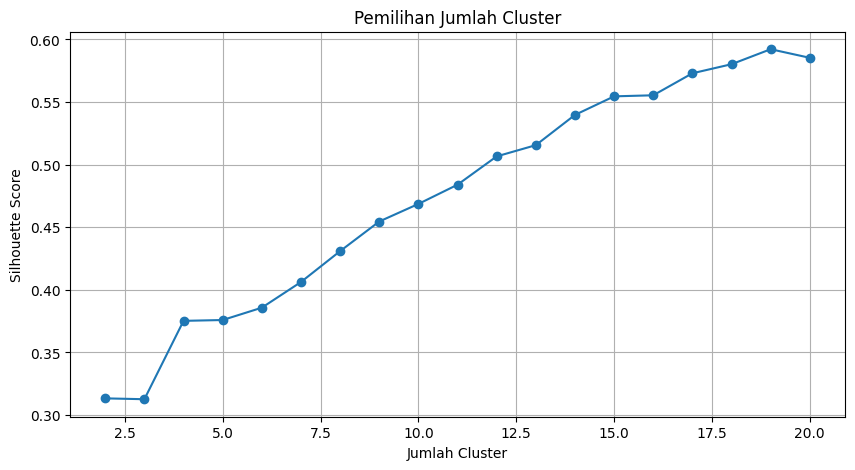

In [57]:
hasil_cluster = pd.DataFrame(hasil_cluster)

display(hasil_cluster.head())

plt.figure(figsize=(10,5))

plt.plot(
    hasil_cluster["K"],
    hasil_cluster["Silhouette"],
    marker="o")

plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Pemilihan Jumlah Cluster")
plt.grid()

plt.show()

In [58]:
kmeans15 = KMeans(
    n_clusters=15,
    random_state=42,
    n_init=10
)

cluster15 = kmeans15.fit_predict(
    X_cluster
)

In [59]:
kmeans19 = KMeans(
    n_clusters=19,
    random_state=42,
    n_init=10
)

cluster19 = kmeans19.fit_predict(
    X_cluster
)

In [60]:
anggota15 = pd.DataFrame({
    "Cluster": range(15),
    "Jumlah_Anggota":
        pd.Series(cluster15)
        .value_counts()
        .sort_index()
        .values
})

anggota15

,Cluster,Jumlah_Anggota
0,0,17
1,1,20
2,2,17
3,3,22
4,4,15
5,5,6
6,6,5
7,7,7
8,8,11
9,9,14


In [61]:
anggota19 = pd.DataFrame({
    "Cluster": range(19),
    "Jumlah_Anggota":
        pd.Series(cluster19)
        .value_counts()
        .sort_index()
        .values
})

anggota19

,Cluster,Jumlah_Anggota
0,0,14
1,1,11
2,2,15
3,3,22
4,4,18
5,5,14
6,6,17
7,7,7
8,8,5
9,9,7
